In [3]:
# ============================================================
# H2: Initialization experiment
# ============================================================

import os
import numpy as np
import pandas as pd
from matplotlib import pyplot as plt
from matplotlib.ticker import PercentFormatter
import importlib

from scratch import *
import scratch

importlib.reload(scratch)


<module 'scratch' from '/Users/debashisgupta/Desktop/Course/K-UTD/Fall-26/DL/K-Project1/Code/scratch.py'>

In [4]:

H2_OUTPUT_DIR = "output/h2/performance"

os.makedirs(
    H2_OUTPUT_DIR,
    exist_ok=True
)


H2_INITIALIZATIONS = [
    "zero",
    "small",
    "xavier",
    "he",
    "large"
]


H2_LEARNING_RATE = 0.1
H2_EPOCHS = 100

EXPERIMENT_EPOCHS = 100
EXPERIMENT_SEEDS = generate_experiment_seeds(base_seed=SPLIT_SEED, number_of_seeds=3)

print("H2 output folder:", H2_OUTPUT_DIR)
print("Initialization methods:", H2_INITIALIZATIONS)
print("Fixed learning rate:", H2_LEARNING_RATE)
print("Experiment seeds:", EXPERIMENT_SEEDS)

print("\nLoading MNIST data...")

train_dataset, test_dataset = load_mnist_data()

print("Preprossing data...")

X_train, y_train, X_val, y_val, X_test, y_test = preprocess_data(
    train_dataset,
    test_dataset,
    train_size=50000,
    test_size=10000,
    SPLIT_SEED=SPLIT_SEED
)


# ============================================================
# Run H2 using three seeds per initialization
# ============================================================

h2_results = {}

for initialization_method in H2_INITIALIZATIONS:
    configuration_name = (
        f"H2: Initialization = {initialization_method}"
    )

    models, histories = run_three_seed_configuration(
        configuration_name=configuration_name,
        X_train=X_train,
        y_train=y_train,
        X_val=X_val,
        y_val=y_val,
        hidden_size=128,
        activation="relu",
        initialization=initialization_method,
        learning_rate=H2_LEARNING_RATE,
        batch_size=128,
        epochs=H2_EPOCHS,
        seeds=EXPERIMENT_SEEDS,
        verbose=True
    )

    h2_results[initialization_method] = {
        "models": models,
        "histories": histories
    }

H2 output folder: output/h2/performance
Initialization methods: ['zero', 'small', 'xavier', 'he', 'large']
Fixed learning rate: 0.1
Experiment seeds: [654571, 89250, 773955]

Loading MNIST data...
Preprossing data...
Original training images: (60000, 28, 28)
Original training labels: (60000,)
Original test images: (10000, 28, 28)
Original test labels: (10000,)
Splitting the training data into training and validation sets...
Training images: (50000, 28, 28)
Training labels: (50000,)
Validation images: (10000, 28, 28)
Validation labels: (10000,)
Test images: (10000, 28, 28)
Test labels: (10000,)
Before Normalization:
Training data range: 0.0 to 255.0
Validation data range: 0.0 to 255.0
Test data range: 0.0 to 255.0
Performing normalization of the data...
After Normalization:
Training data range: 0.0 to 1.0
Validation data range: 0.0 to 1.0
Test data range: 0.0 to 1.0
Configuration: H2: Initialization = zero
Seeds: [654571, 89250, 773955]

Run 1/3 using seed 654571
Epoch 1: Train loss=2.3

In [5]:
# ============================================================
# H2 final-epoch summary
# ============================================================

h2_summary_rows = []

for initialization_method, result in h2_results.items():
    histories = result["histories"]

    final_train_accuracy = np.array([
        history["train_accuracy"][-1]
        for history in histories
    ])

    final_val_accuracy = np.array([
        history["val_accuracy"][-1]
        for history in histories
    ])

    final_train_loss = np.array([
        history["train_loss"][-1]
        for history in histories
    ])

    final_val_loss = np.array([
        history["val_loss"][-1]
        for history in histories
    ])

    mean_train_accuracy = np.mean(
        final_train_accuracy
    )

    std_train_accuracy = np.std(
        final_train_accuracy,
        ddof=1
    )

    mean_val_accuracy = np.mean(
        final_val_accuracy
    )

    std_val_accuracy = np.std(
        final_val_accuracy,
        ddof=1
    )

    mean_train_loss = np.mean(
        final_train_loss
    )

    std_train_loss = np.std(
        final_train_loss,
        ddof=1
    )

    mean_val_loss = np.mean(
        final_val_loss
    )

    std_val_loss = np.std(
        final_val_loss,
        ddof=1
    )

    h2_summary_rows.append({
        "Initialization": initialization_method,

        "Train Accuracy Mean": (
            f"{mean_train_accuracy * 100:.2f}%"
        ),

        "Train Accuracy SD": (
            f"{std_train_accuracy * 100:.2f}%"
        ),

        "Train Accuracy Mean ± SD": (
            f"{mean_train_accuracy * 100:.2f}% ± "
            f"{std_train_accuracy * 100:.2f}%"
        ),

        "Validation Accuracy Mean": (
            f"{mean_val_accuracy * 100:.2f}%"
        ),

        "Validation Accuracy SD": (
            f"{std_val_accuracy * 100:.2f}%"
        ),

        "Validation Accuracy Mean ± SD": (
            f"{mean_val_accuracy * 100:.2f}% ± "
            f"{std_val_accuracy * 100:.2f}%"
        ),

        "Train Loss Mean": (
            f"{mean_train_loss:.4f}"
        ),

        "Train Loss SD": (
            f"{std_train_loss:.4f}"
        ),

        "Train Loss Mean ± SD": (
            f"{mean_train_loss:.4f} ± "
            f"{std_train_loss:.4f}"
        ),

        "Validation Loss Mean": (
            f"{mean_val_loss:.4f}"
        ),

        "Validation Loss SD": (
            f"{std_val_loss:.4f}"
        ),

        "Validation Loss Mean ± SD": (
            f"{mean_val_loss:.4f} ± "
            f"{std_val_loss:.4f}"
        )
    })


h2_summary_table = pd.DataFrame(
    h2_summary_rows
)


print("\nH2 final-epoch results across three seeds")

display(h2_summary_table)


H2 final-epoch results across three seeds


,Initialization,Train Accuracy Mean,Train Accuracy SD,Train Accuracy Mean ± SD,Validation Accuracy Mean,Validation Accuracy SD,Validation Accuracy Mean ± SD,Train Loss Mean,Train Loss SD,Train Loss Mean ± SD,Validation Loss Mean,Validation Loss SD,Validation Loss Mean ± SD
0,zero,11.30%,0.00%,11.30% ± 0.00%,10.93%,0.00%,10.93% ± 0.00%,2.3013,0.0000,2.3013 ± 0.0000,2.3018,0.0000,2.3018 ± 0.0000
1,small,99.98%,0.00%,99.98% ± 0.00%,97.86%,0.09%,97.86% ± 0.09%,0.0057,0.0002,0.0057 ± 0.0002,0.0776,0.0027,0.0776 ± 0.0027
2,xavier,99.99%,0.01%,99.99% ± 0.01%,97.82%,0.06%,97.82% ± 0.06%,0.0051,0.0002,0.0051 ± 0.0002,0.0817,0.0040,0.0817 ± 0.0040
3,he,99.99%,0.00%,99.99% ± 0.00%,97.79%,0.07%,97.79% ± 0.07%,0.0049,0.0001,0.0049 ± 0.0001,0.0842,0.0030,0.0842 ± 0.0030
4,large,97.55%,0.20%,97.55% ± 0.20%,94.55%,0.23%,94.55% ± 0.23%,0.0828,0.0060,0.0828 ± 0.0060,0.2349,0.0123,0.2349 ± 0.0123


Saved: output/h2/performance/h2_summary.csv
Saved: output/h2/performance/h2_epoch_history.csv
Saved: output/h2/performance/h2_initialization_zero.png


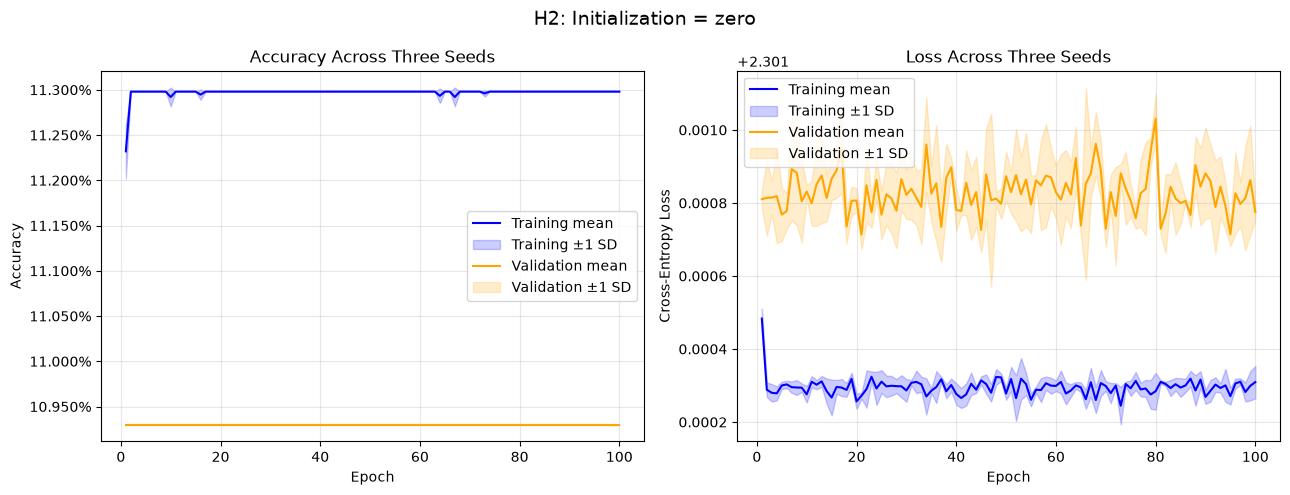

Saved: output/h2/performance/h2_initialization_small.png


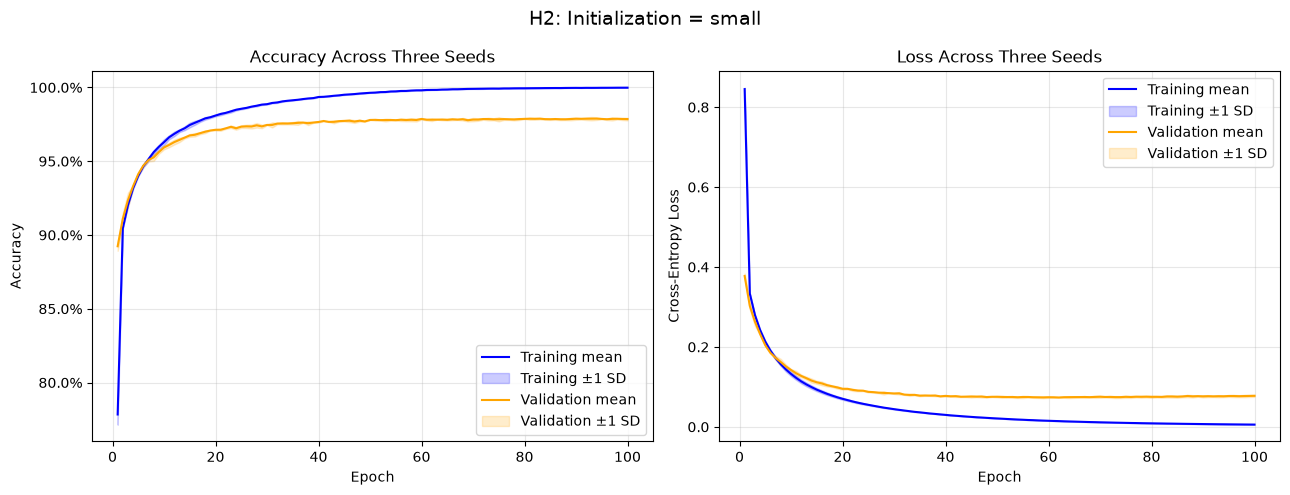

Saved: output/h2/performance/h2_initialization_xavier.png


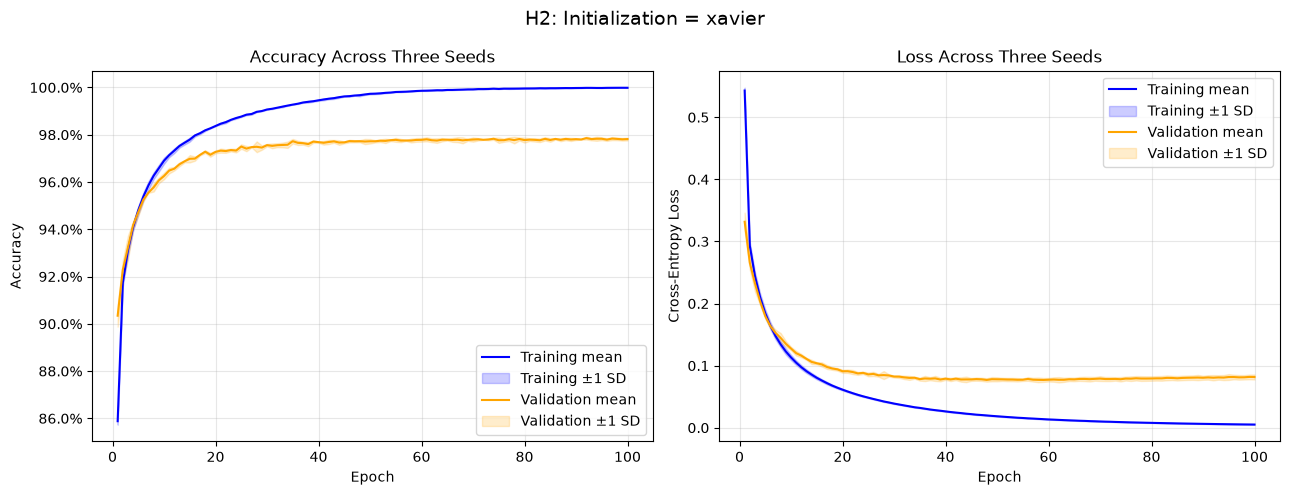

Saved: output/h2/performance/h2_initialization_he.png


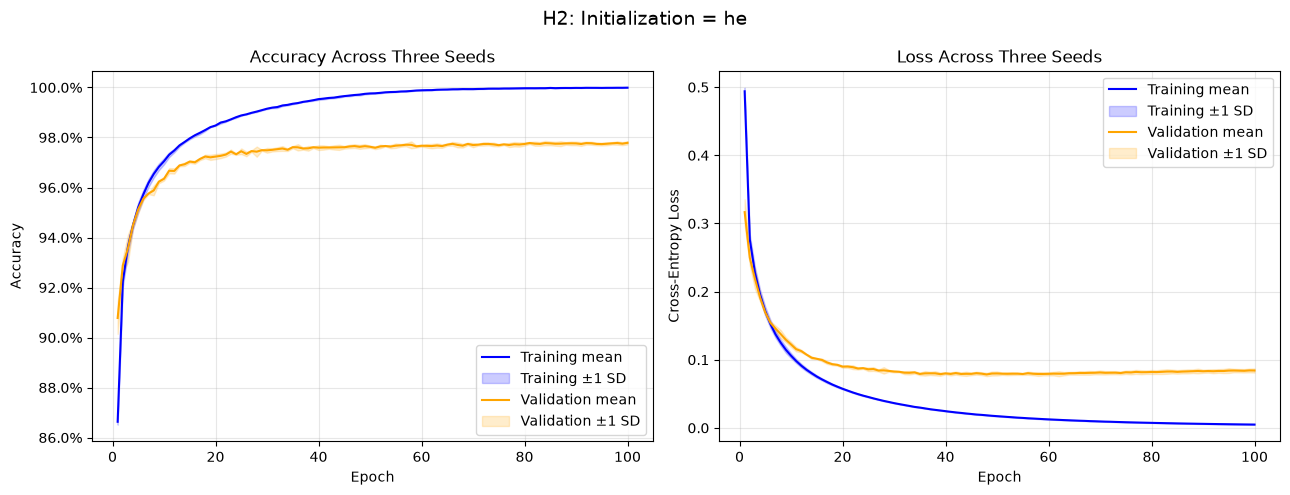

Saved: output/h2/performance/h2_initialization_large.png


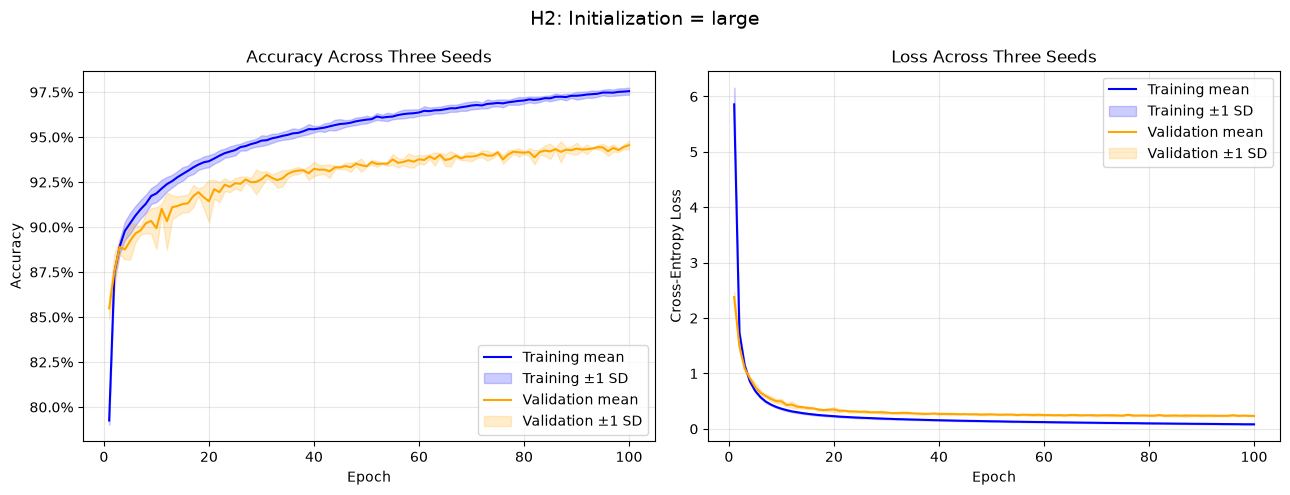

In [6]:

h2_summary_path = os.path.join(
    H2_OUTPUT_DIR,
    "h2_summary.csv"
)

h2_summary_table.to_csv(
    h2_summary_path,
    index=False
)


print("Saved:", h2_summary_path)
# ============================================================
# Save raw H2 epoch histories
# ============================================================

h2_history_rows = []

for initialization_method, result in h2_results.items():
    histories = result["histories"]

    for seed, history in zip(
        EXPERIMENT_SEEDS,
        histories
    ):
        number_of_epochs = len(
            history["train_loss"]
        )

        for epoch_index in range(number_of_epochs):
            h2_history_rows.append({
                "initialization": initialization_method,
                "seed": seed,
                "epoch": epoch_index + 1,

                "train_loss": (
                    history["train_loss"][epoch_index]
                ),

                "train_accuracy": (
                    history["train_accuracy"][epoch_index]
                ),

                "validation_loss": (
                    history["val_loss"][epoch_index]
                ),

                "validation_accuracy": (
                    history["val_accuracy"][epoch_index]
                )
            })


h2_history_table = pd.DataFrame(
    h2_history_rows
)


h2_history_path = os.path.join(
    H2_OUTPUT_DIR,
    "h2_epoch_history.csv"
)


h2_history_table.to_csv(
    h2_history_path,
    index=False
)


print("Saved:", h2_history_path)

# ============================================================
# Save one two-panel plot per initialization
# ============================================================

for initialization_method, result in h2_results.items():
    plot_path = os.path.join(
        H2_OUTPUT_DIR,
        f"h2_initialization_{initialization_method}.png"
    )

    plot_and_save_three_seed_results(
        histories=result["histories"],
        configuration_name=(
            f"H2: Initialization = "
            f"{initialization_method}"
        ),
        save_path=plot_path
    )

H2 diagnostic output: output/h2/network_diagnostics
Initializations: ['zero', 'small', 'xavier', 'he', 'large']
Seeds: [654571, 89250, 773955]

Diagnostic X shape: (1000, 784)
Diagnostic y shape: (1000,)
Diagnostic class counts: [100 100 100 100 100 100 100 100 100 100]

Initial network measurements


,initialization,seed,initial_loss,W1_norm,W2_norm,Z1_mean,Z1_std,A1_mean,A1_std,logits_mean,logits_std,zero_activation_fraction,dW1_norm,db1_norm,dW2_norm,db2_norm,dW1_rms,dW2_rms
0,zero,654571,2.302585,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,0.000000,0.000000,0.000000,3.492047e-15,0.000000,0.000000
1,zero,89250,2.302585,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,0.000000,0.000000,0.000000,3.492047e-15,0.000000,0.000000
2,zero,773955,2.302585,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,0.000000,0.000000,0.000000,3.492047e-15,0.000000,0.000000
3,small,654571,2.302084,3.166724,0.361043,0.003535,0.092438,0.038345,0.055299,0.002661,0.008075,0.482039,0.079132,0.005861,0.071041,1.870419e-03,0.000250,0.001986
4,small,89250,2.302354,3.177291,0.364059,-0.006214,0.089188,0.032250,0.049777,0.000638,0.005676,0.527078,0.075643,0.006095,0.061277,1.005265e-03,0.000239,0.001713
5,small,773955,2.301545,3.165880,0.365781,0.003644,0.095202,0.039218,0.055797,0.002222,0.008866,0.476172,0.081680,0.005665,0.069990,2.224596e-03,0.000258,0.001956
6,xavier,654571,2.317688,11.309730,3.191203,0.012626,0.330136,0.136945,0.197498,0.084013,0.254915,0.482039,0.722045,0.061162,0.277080,6.355240e-02,0.002279,0.007745
7,xavier,89250,2.309422,11.347468,3.217858,-0.022192,0.318530,0.115178,0.177775,0.020151,0.179189,0.527078,0.681567,0.055507,0.226184,3.097734e-02,0.002152,0.006322
8,xavier,773955,2.305039,11.306715,3.233079,0.013014,0.340008,0.140064,0.199273,0.070132,0.279874,0.476172,0.774862,0.070718,0.287638,6.777997e-02,0.002446,0.008040
9,he,654571,2.400491,15.994373,4.513043,0.017857,0.466882,0.193670,0.279304,0.168026,0.509830,0.482039,1.220576,0.133460,0.531448,1.369044e-01,0.003853,0.014854


Saved: output/h2/network_diagnostics/h2_initial_network_diagnostics.csv

Initial diagnostics: mean and SD


,initialization,initial_loss_mean,initial_loss_std,W1_norm_mean,W1_norm_std,W2_norm_mean,W2_norm_std,Z1_std_mean,Z1_std_std,A1_std_mean,...,db1_norm_mean,db1_norm_std,dW2_norm_mean,dW2_norm_std,db2_norm_mean,db2_norm_std,dW1_rms_mean,dW1_rms_std,dW2_rms_mean,dW2_rms_std
0,he,2.373695,0.028007,16.010742,0.032115,4.545348,0.029976,0.466065,0.015204,0.270844,...,0.124293,0.033222,0.468894,0.106086,1.099003e-01,0.043099,0.003709,0.000477,0.013106,0.002965
1,large,115.216487,29.382481,316.996521,0.635841,36.362784,0.239809,9.227615,0.301021,5.362433,...,3.520843,1.400569,28.995674,11.512247,4.994047e-01,0.178869,0.074390,0.025292,0.810454,0.321777
2,small,2.301994,0.000412,3.169965,0.006358,0.363628,0.002398,0.092276,0.003010,0.053624,...,0.005874,0.000215,0.067436,0.005360,1.700094e-03,0.000627,0.000249,0.000010,0.001885,0.000150
3,xavier,2.310716,0.006423,11.321304,0.022709,3.214046,0.021196,0.329558,0.010751,0.191515,...,0.062462,0.007688,0.263634,0.032859,5.410324e-02,0.020139,0.002292,0.000148,0.007369,0.000918
4,zero,2.302585,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,3.492047e-15,0.000000,0.000000,0.000000,0.000000,0.000000


Saved: output/h2/network_diagnostics/h2_initial_network_summary.csv

H2 initialization: zero

Run 1/3, seed=654571
Epoch   1/100 | train loss=2.3015 | val loss=2.3018 | dW1 RMS=0.000e+00 | dW2 RMS=0.000e+00
Epoch  10/100 | train loss=2.3013 | val loss=2.3018 | dW1 RMS=0.000e+00 | dW2 RMS=0.000e+00
Epoch  20/100 | train loss=2.3012 | val loss=2.3018 | dW1 RMS=0.000e+00 | dW2 RMS=0.000e+00
Epoch  30/100 | train loss=2.3013 | val loss=2.3018 | dW1 RMS=0.000e+00 | dW2 RMS=0.000e+00
Epoch  40/100 | train loss=2.3013 | val loss=2.3018 | dW1 RMS=0.000e+00 | dW2 RMS=0.000e+00
Epoch  50/100 | train loss=2.3013 | val loss=2.3019 | dW1 RMS=0.000e+00 | dW2 RMS=0.000e+00
Epoch  60/100 | train loss=2.3013 | val loss=2.3018 | dW1 RMS=0.000e+00 | dW2 RMS=0.000e+00
Epoch  70/100 | train loss=2.3013 | val loss=2.3018 | dW1 RMS=0.000e+00 | dW2 RMS=0.000e+00
Epoch  80/100 | train loss=2.3012 | val loss=2.3021 | dW1 RMS=0.000e+00 | dW2 RMS=0.000e+00
Epoch  90/100 | train loss=2.3012 | val loss=2.3019 | dW1

,initialization,seed,status,failure_message,epochs_completed
0,zero,654571,completed,,100
1,zero,89250,completed,,100
2,zero,773955,completed,,100
3,small,654571,completed,,100
4,small,89250,completed,,100
5,small,773955,completed,,100
6,xavier,654571,completed,,100
7,xavier,89250,completed,,100
8,xavier,773955,completed,,100
9,he,654571,completed,,100


Saved: output/h2/network_diagnostics/h2_run_status.csv
Saved: output/h2/network_diagnostics/h2_gradient_and_performance_history.csv
Saved: output/h2/network_diagnostics/h2_network_diagnostics.png


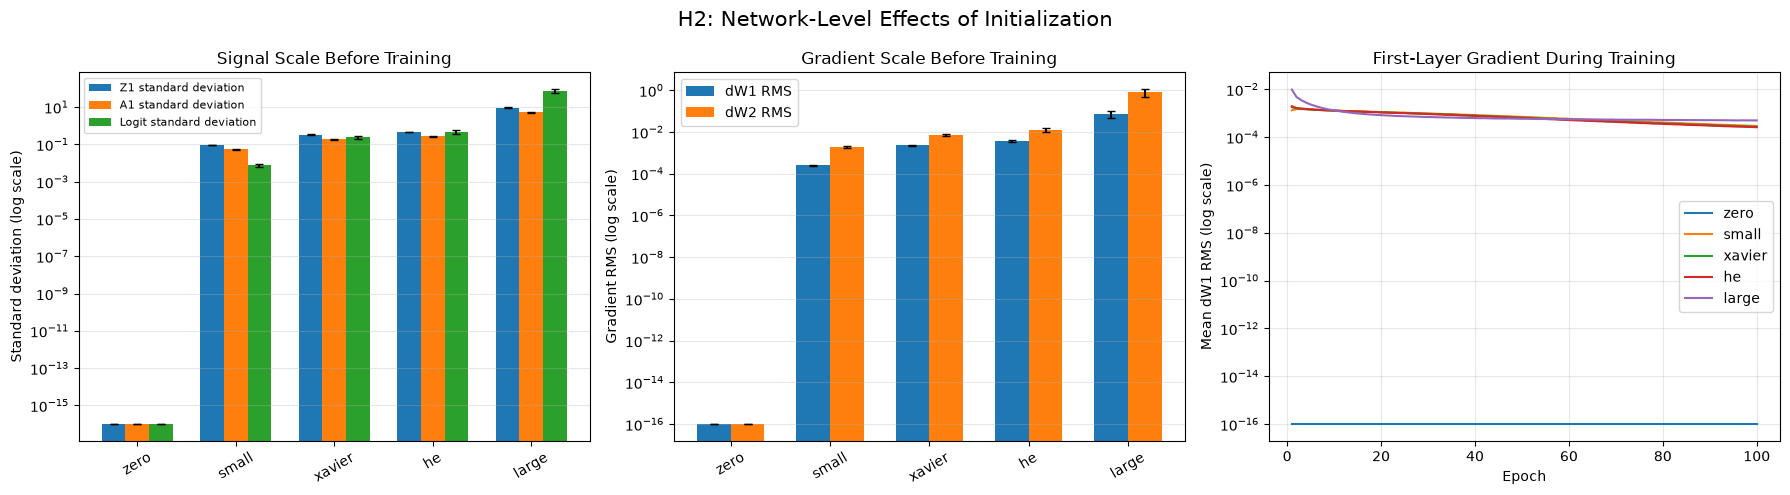

Saved: output/h2/network_diagnostics/h2_performance_zero.png


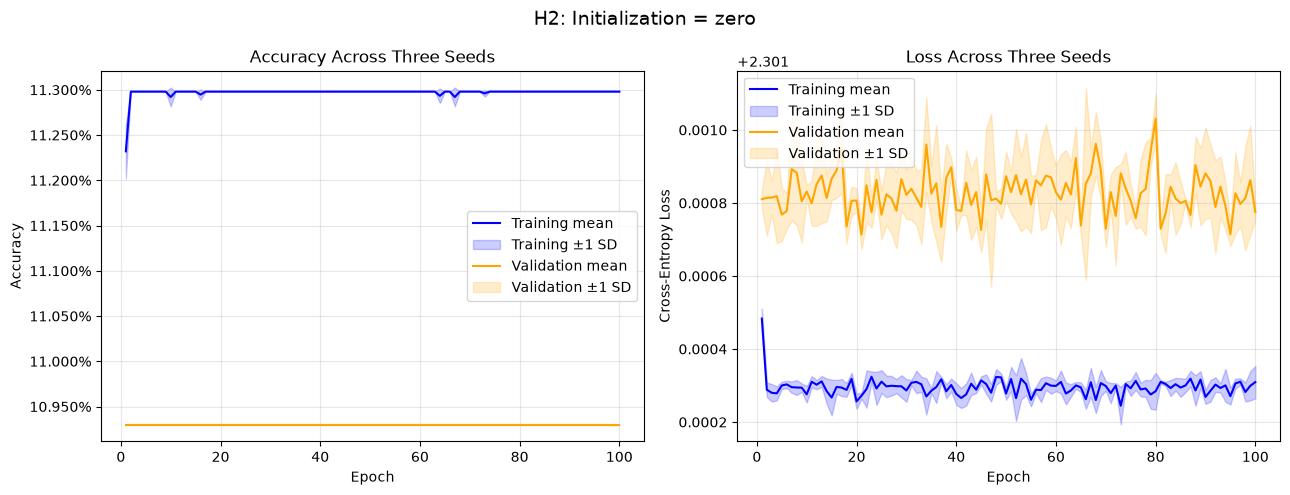

Saved: output/h2/network_diagnostics/h2_performance_small.png


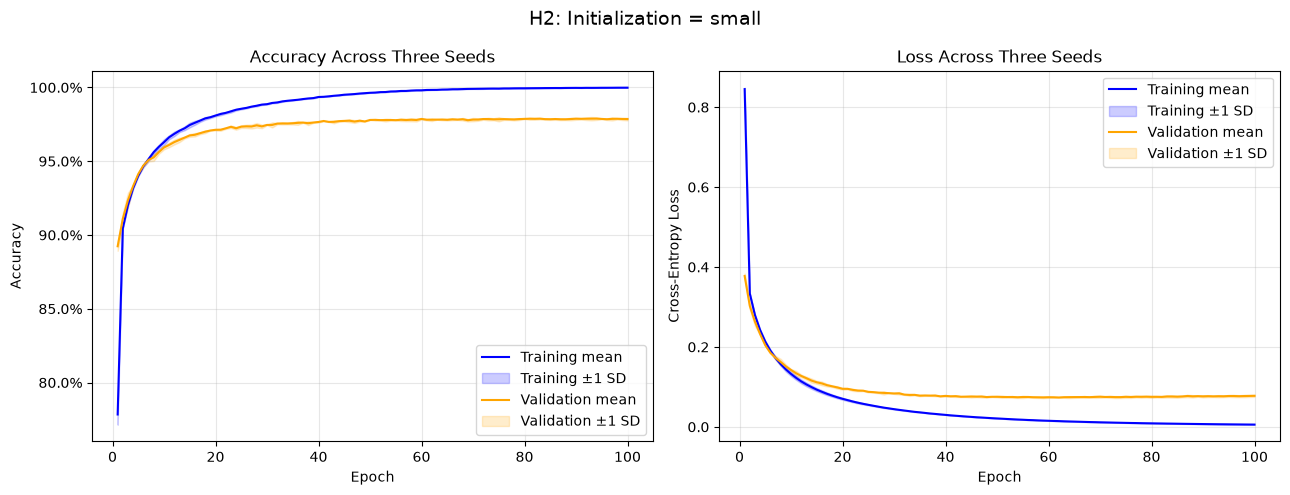

Saved: output/h2/network_diagnostics/h2_performance_xavier.png


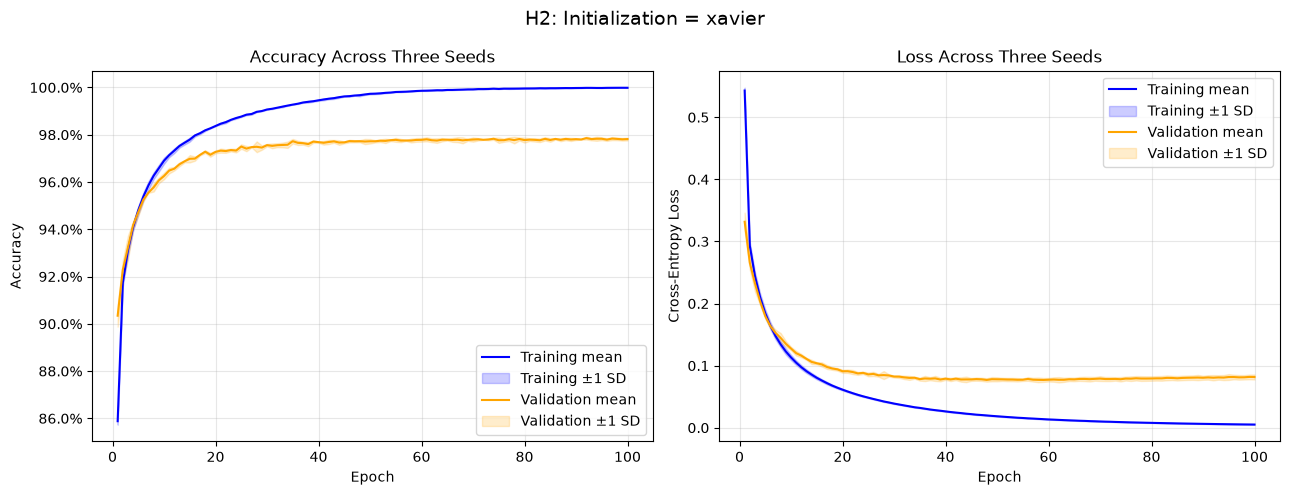

Saved: output/h2/network_diagnostics/h2_performance_he.png


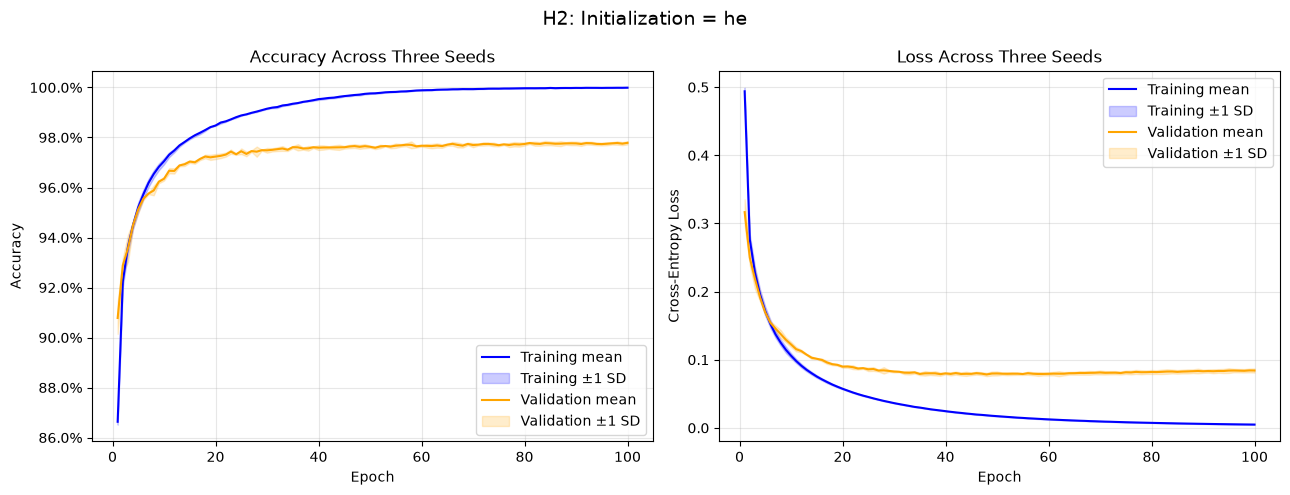

Saved: output/h2/network_diagnostics/h2_performance_large.png


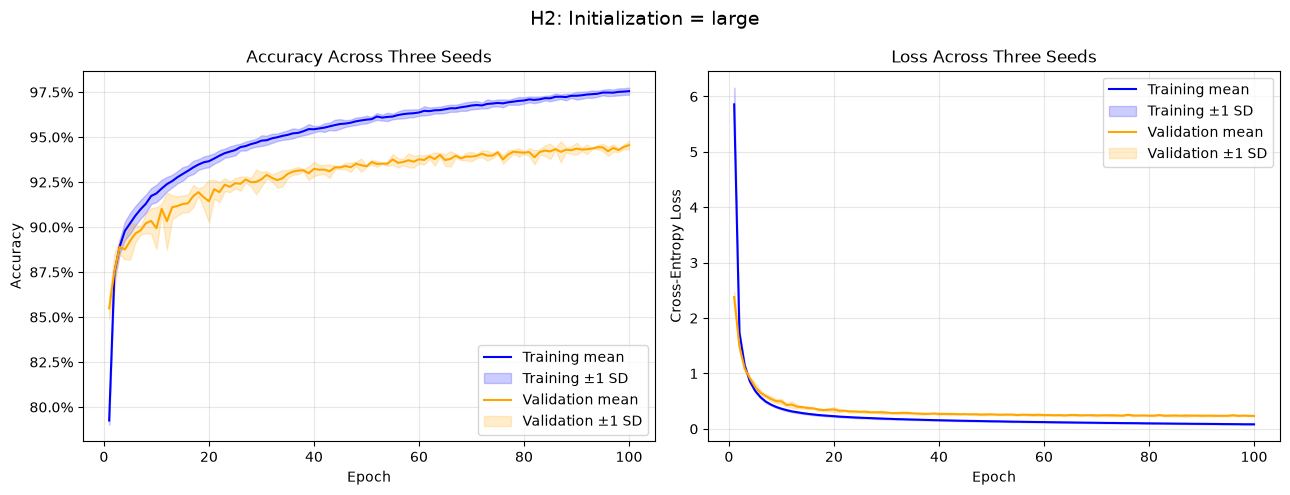


Files saved in output/h2:
h2_gradient_and_performance_history.csv
h2_initial_network_diagnostics.csv
h2_initial_network_summary.csv
h2_network_diagnostics.png
h2_performance_he.png
h2_performance_large.png
h2_performance_small.png
h2_performance_xavier.png
h2_performance_zero.png
h2_run_status.csv


In [7]:
# ============================================================
# H2 NETWORK-LEVEL INITIALIZATION ANALYSIS
# All new names start with h2diag_ to avoid conflicts
# ============================================================

import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt


# ============================================================
# 1. H2 diagnostic settings
# ============================================================

H2DIAG_OUTPUT_DIR = "output/h2/network_diagnostics"

os.makedirs(
    H2DIAG_OUTPUT_DIR,
    exist_ok=True
)


H2DIAG_INITIALIZATIONS = [
    "zero",
    "small",
    "xavier",
    "he",
    "large"
]


H2DIAG_LEARNING_RATE = 0.1
H2DIAG_BATCH_SIZE = 128
H2DIAG_EPOCHS = 100
H2DIAG_HIDDEN_SIZE = 128
H2DIAG_EXPERIMENT_SEEDS=EXPERIMENT_SEEDS


print("H2 diagnostic output:", H2DIAG_OUTPUT_DIR)
print("Initializations:", H2DIAG_INITIALIZATIONS)
print("Seeds:", H2DIAG_EXPERIMENT_SEEDS)

# ============================================================
# 2. Create one fixed balanced diagnostic batch
#    100 examples per digit = 1,000 examples
# ============================================================

h2diag_indices = []

for digit in range(10):
    digit_indices = np.where(
        y_train == digit
    )[0]

    h2diag_indices.extend(
        digit_indices[:100]
    )


h2diag_indices = np.array(
    h2diag_indices
)


h2diag_X = X_train[h2diag_indices]
h2diag_y = y_train[h2diag_indices]


print("\nDiagnostic X shape:", h2diag_X.shape)
print("Diagnostic y shape:", h2diag_y.shape)
print(
    "Diagnostic class counts:",
    np.bincount(h2diag_y)
)


# ============================================================
# 3. Helper for calculating gradient RMS
# ============================================================

def h2diag_gradient_rms(gradient):
    return (
        np.linalg.norm(gradient)
        / np.sqrt(gradient.size)
    )


# ============================================================
# 4. Measure the network immediately after initialization
#    No training update occurs here
# ============================================================

h2diag_initial_rows = []


for initialization_method in H2DIAG_INITIALIZATIONS:
    for seed in H2DIAG_EXPERIMENT_SEEDS:
        parameters = initialize_parameters(
            input_size=784,
            hidden_size=H2DIAG_HIDDEN_SIZE,
            output_size=10,
            initialization=initialization_method,
            seed=seed
        )

        with np.errstate(
            over="ignore",
            invalid="ignore"
        ):
            probabilities, cache = forward_pass(
                h2diag_X,
                parameters,
                activation="relu"
            )

            initial_loss = cross_entropy_loss(
                cache["logits"],
                h2diag_y
            )

            gradients = backward_pass(
                h2diag_y,
                parameters,
                cache,
                activation="relu"
            )

        Z1 = cache["Z1"]
        A1 = cache["A1"]
        logits = cache["logits"]

        h2diag_initial_rows.append({
            "initialization": initialization_method,
            "seed": seed,

            "initial_loss": initial_loss,

            "W1_norm": np.linalg.norm(
                parameters["W1"]
            ),

            "W2_norm": np.linalg.norm(
                parameters["W2"]
            ),

            "Z1_mean": np.mean(Z1),
            "Z1_std": np.std(Z1),

            "A1_mean": np.mean(A1),
            "A1_std": np.std(A1),

            "logits_mean": np.mean(logits),
            "logits_std": np.std(logits),

            "zero_activation_fraction": np.mean(
                A1 == 0.0
            ),

            "dW1_norm": np.linalg.norm(
                gradients["dW1"]
            ),

            "db1_norm": np.linalg.norm(
                gradients["db1"]
            ),

            "dW2_norm": np.linalg.norm(
                gradients["dW2"]
            ),

            "db2_norm": np.linalg.norm(
                gradients["db2"]
            ),

            "dW1_rms": h2diag_gradient_rms(
                gradients["dW1"]
            ),

            "dW2_rms": h2diag_gradient_rms(
                gradients["dW2"]
            )
        })


h2diag_initial_table = pd.DataFrame(
    h2diag_initial_rows
)


print("\nInitial network measurements")
display(h2diag_initial_table)


h2diag_initial_path = os.path.join(
    H2DIAG_OUTPUT_DIR,
    "h2_initial_network_diagnostics.csv"
)


h2diag_initial_table.to_csv(
    h2diag_initial_path,
    index=False
)


print("Saved:", h2diag_initial_path)


# ============================================================
# 5. Create mean and SD initial-diagnostic table
# ============================================================

h2diag_initial_metrics = [
    "initial_loss",
    "W1_norm",
    "W2_norm",
    "Z1_std",
    "A1_std",
    "logits_std",
    "zero_activation_fraction",
    "dW1_norm",
    "db1_norm",
    "dW2_norm",
    "db2_norm",
    "dW1_rms",
    "dW2_rms"
]


h2diag_initial_summary = (
    h2diag_initial_table
    .groupby("initialization")[
        h2diag_initial_metrics
    ]
    .agg(["mean", "std"])
    .reset_index()
)


# Flatten the two-level column names
h2diag_initial_summary.columns = [
    (
        column[0]
        if column[1] == ""
        else f"{column[0]}_{column[1]}"
    )
    for column in h2diag_initial_summary.columns
]


print("\nInitial diagnostics: mean and SD")
display(h2diag_initial_summary)


h2diag_initial_summary_path = os.path.join(
    H2DIAG_OUTPUT_DIR,
    "h2_initial_network_summary.csv"
)


h2diag_initial_summary.to_csv(
    h2diag_initial_summary_path,
    index=False
)


print("Saved:", h2diag_initial_summary_path)


# ============================================================
# 6. Separate training function that tracks gradient RMS
# ============================================================

def h2diag_train_model(
    X_train_data,
    y_train_data,
    X_val_data,
    y_val_data,
    initialization,
    seed,
    hidden_size=128,
    activation="relu",
    learning_rate=0.1,
    batch_size=128,
    epochs=100
):
    rng = np.random.default_rng(seed)

    parameters = initialize_parameters(
        input_size=X_train_data.shape[1],
        hidden_size=hidden_size,
        output_size=10,
        initialization=initialization,
        seed=seed
    )

    history = {
        "train_loss": [],
        "train_accuracy": [],
        "val_loss": [],
        "val_accuracy": [],
        "dW1_rms": [],
        "dW2_rms": []
    }

    number_of_examples = X_train_data.shape[0]

    status = "completed"
    failure_message = ""

    for epoch in range(epochs):
        shuffled_indices = rng.permutation(
            number_of_examples
        )

        epoch_loss_sum = 0.0
        epoch_correct = 0

        epoch_dW1_rms = []
        epoch_dW2_rms = []

        epoch_failed = False

        for start in range(
            0,
            number_of_examples,
            batch_size
        ):
            end = min(
                start + batch_size,
                number_of_examples
            )

            batch_indices = shuffled_indices[start:end]

            X_batch = X_train_data[batch_indices]
            y_batch = y_train_data[batch_indices]

            with np.errstate(
                over="ignore",
                invalid="ignore"
            ):
                probabilities, cache = forward_pass(
                    X_batch,
                    parameters,
                    activation
                )

                batch_loss = cross_entropy_loss(
                    cache["logits"],
                    y_batch
                )

            if not np.isfinite(batch_loss):
                status = "failed"
                failure_message = (
                    f"Non-finite loss at epoch "
                    f"{epoch + 1}"
                )
                epoch_failed = True
                break

            gradients = backward_pass(
                y_batch,
                parameters,
                cache,
                activation
            )

            gradients_are_finite = all(
                np.all(np.isfinite(gradient))
                for gradient in gradients.values()
            )

            if not gradients_are_finite:
                status = "failed"
                failure_message = (
                    f"Non-finite gradient at epoch "
                    f"{epoch + 1}"
                )
                epoch_failed = True
                break

            epoch_dW1_rms.append(
                h2diag_gradient_rms(
                    gradients["dW1"]
                )
            )

            epoch_dW2_rms.append(
                h2diag_gradient_rms(
                    gradients["dW2"]
                )
            )

            epoch_loss_sum += (
                batch_loss * X_batch.shape[0]
            )

            predictions = np.argmax(
                probabilities,
                axis=1
            )

            epoch_correct += np.sum(
                predictions == y_batch
            )

            parameters = update_parameters(
                parameters,
                gradients,
                learning_rate
            )

        if epoch_failed:
            break

        train_loss = (
            epoch_loss_sum / number_of_examples
        )

        train_accuracy = (
            epoch_correct / number_of_examples
        )

        with np.errstate(
            over="ignore",
            invalid="ignore"
        ):
            val_loss, val_accuracy = evaluate_model(
                X_val_data,
                y_val_data,
                parameters,
                activation
            )

        if not np.isfinite(val_loss):
            status = "failed"
            failure_message = (
                f"Non-finite validation loss at "
                f"epoch {epoch + 1}"
            )
            break

        history["train_loss"].append(
            train_loss
        )

        history["train_accuracy"].append(
            train_accuracy
        )

        history["val_loss"].append(
            val_loss
        )

        history["val_accuracy"].append(
            val_accuracy
        )

        history["dW1_rms"].append(
            np.mean(epoch_dW1_rms)
        )

        history["dW2_rms"].append(
            np.mean(epoch_dW2_rms)
        )

        if (
            epoch == 0
            or (epoch + 1) % 10 == 0
            or epoch == epochs - 1
        ):
            print(
                f"Epoch {epoch + 1:3d}/{epochs} | "
                f"train loss={train_loss:.4f} | "
                f"val loss={val_loss:.4f} | "
                f"dW1 RMS={history['dW1_rms'][-1]:.3e} | "
                f"dW2 RMS={history['dW2_rms'][-1]:.3e}"
            )

    return parameters, history, status, failure_message


# ============================================================
# 7. Run all H2 initialization configurations
# ============================================================

h2diag_results = {}
h2diag_status_rows = []


for initialization_method in H2DIAG_INITIALIZATIONS:
    print("\n" + "=" * 75)
    print(
        "H2 initialization:",
        initialization_method
    )
    print("=" * 75)

    models = {}
    histories = []
    statuses = {}

    for run_number, seed in enumerate(
        H2DIAG_EXPERIMENT_SEEDS,
        start=1
    ):
        print(
            f"\nRun {run_number}/"
            f"{len(H2DIAG_EXPERIMENT_SEEDS)}, "
            f"seed={seed}"
        )

        (
            parameters,
            history,
            status,
            failure_message
        ) = h2diag_train_model(
            X_train_data=X_train,
            y_train_data=y_train,
            X_val_data=X_val,
            y_val_data=y_val,
            initialization=initialization_method,
            seed=seed,
            hidden_size=H2DIAG_HIDDEN_SIZE,
            activation="relu",
            learning_rate=H2DIAG_LEARNING_RATE,
            batch_size=H2DIAG_BATCH_SIZE,
            epochs=H2DIAG_EPOCHS
        )

        models[seed] = parameters
        histories.append(history)
        statuses[seed] = status

        h2diag_status_rows.append({
            "initialization": initialization_method,
            "seed": seed,
            "status": status,
            "failure_message": failure_message,
            "epochs_completed": len(
                history["train_loss"]
            )
        })

        if status == "completed":
            print(
                f"Completed | "
                f"final val accuracy="
                f"{history['val_accuracy'][-1] * 100:.2f}%"
            )
        else:
            print(
                "FAILED:",
                failure_message
            )

    h2diag_results[initialization_method] = {
        "models": models,
        "histories": histories,
        "statuses": statuses
    }


# ============================================================
# 8. Save training status
# ============================================================

h2diag_status_table = pd.DataFrame(
    h2diag_status_rows
)


print("\nH2 run status")
display(h2diag_status_table)


h2diag_status_path = os.path.join(
    H2DIAG_OUTPUT_DIR,
    "h2_run_status.csv"
)


h2diag_status_table.to_csv(
    h2diag_status_path,
    index=False
)


print("Saved:", h2diag_status_path)


# ============================================================
# 9. Save epoch-level performance and gradient history
# ============================================================

h2diag_epoch_rows = []


for initialization_method, result in h2diag_results.items():
    for seed, history in zip(
        H2DIAG_EXPERIMENT_SEEDS,
        result["histories"]
    ):
        completed_epochs = len(
            history["train_loss"]
        )

        for epoch_index in range(completed_epochs):
            h2diag_epoch_rows.append({
                "initialization": initialization_method,
                "seed": seed,
                "epoch": epoch_index + 1,

                "train_loss": (
                    history["train_loss"][epoch_index]
                ),

                "train_accuracy": (
                    history["train_accuracy"][epoch_index]
                ),

                "validation_loss": (
                    history["val_loss"][epoch_index]
                ),

                "validation_accuracy": (
                    history["val_accuracy"][epoch_index]
                ),

                "dW1_rms": (
                    history["dW1_rms"][epoch_index]
                ),

                "dW2_rms": (
                    history["dW2_rms"][epoch_index]
                )
            })


h2diag_epoch_table = pd.DataFrame(
    h2diag_epoch_rows
)


h2diag_epoch_path = os.path.join(
    H2DIAG_OUTPUT_DIR,
    "h2_gradient_and_performance_history.csv"
)


h2diag_epoch_table.to_csv(
    h2diag_epoch_path,
    index=False
)


print("Saved:", h2diag_epoch_path)


# ============================================================
# 10. Create the three-panel network-diagnostic figure
# ============================================================

h2diag_method_order = H2DIAG_INITIALIZATIONS

h2diag_grouped_initial = (
    h2diag_initial_table
    .groupby("initialization")
)


h2diag_x = np.arange(
    len(h2diag_method_order)
)


h2diag_epsilon = 1e-16


fig, axes = plt.subplots(
    1,
    3,
    figsize=(18, 5)
)


# ------------------------------------------------------------
# Panel 1: Initial activation scales
# ------------------------------------------------------------

activation_metrics = [
    ("Z1_std", "Z1 standard deviation"),
    ("A1_std", "A1 standard deviation"),
    ("logits_std", "Logit standard deviation")
]


bar_width = 0.24


for metric_index, (
    metric_name,
    metric_label
) in enumerate(activation_metrics):
    means = np.array([
        h2diag_grouped_initial
        .get_group(method)[metric_name]
        .mean()
        for method in h2diag_method_order
    ])

    standard_deviations = np.array([
        h2diag_grouped_initial
        .get_group(method)[metric_name]
        .std(ddof=1)
        for method in h2diag_method_order
    ])

    plot_means = np.maximum(
        means,
        h2diag_epsilon
    )

    axes[0].bar(
        h2diag_x
        + (metric_index - 1) * bar_width,
        plot_means,
        width=bar_width,
        yerr=standard_deviations,
        capsize=3,
        label=metric_label
    )


axes[0].set_yscale("log")
axes[0].set_xticks(h2diag_x)
axes[0].set_xticklabels(
    h2diag_method_order,
    rotation=30
)
axes[0].set_title(
    "Signal Scale Before Training"
)
axes[0].set_ylabel(
    "Standard deviation (log scale)"
)
axes[0].legend(fontsize=8)
axes[0].grid(
    axis="y",
    alpha=0.3
)


# ------------------------------------------------------------
# Panel 2: Initial gradient RMS
# ------------------------------------------------------------

gradient_metrics = [
    ("dW1_rms", "dW1 RMS"),
    ("dW2_rms", "dW2 RMS")
]


gradient_bar_width = 0.34


for metric_index, (
    metric_name,
    metric_label
) in enumerate(gradient_metrics):
    means = np.array([
        h2diag_grouped_initial
        .get_group(method)[metric_name]
        .mean()
        for method in h2diag_method_order
    ])

    standard_deviations = np.array([
        h2diag_grouped_initial
        .get_group(method)[metric_name]
        .std(ddof=1)
        for method in h2diag_method_order
    ])

    plot_means = np.maximum(
        means,
        h2diag_epsilon
    )

    axes[1].bar(
        h2diag_x
        + (metric_index - 0.5)
        * gradient_bar_width,
        plot_means,
        width=gradient_bar_width,
        yerr=standard_deviations,
        capsize=3,
        label=metric_label
    )


axes[1].set_yscale("log")
axes[1].set_xticks(h2diag_x)
axes[1].set_xticklabels(
    h2diag_method_order,
    rotation=30
)
axes[1].set_title(
    "Gradient Scale Before Training"
)
axes[1].set_ylabel(
    "Gradient RMS (log scale)"
)
axes[1].legend()
axes[1].grid(
    axis="y",
    alpha=0.3
)


# ------------------------------------------------------------
# Panel 3: dW1 gradient RMS over training
# ------------------------------------------------------------

for initialization_method in h2diag_method_order:
    method_data = h2diag_epoch_table[
        h2diag_epoch_table["initialization"]
        == initialization_method
    ]

    if len(method_data) == 0:
        continue

    method_summary = (
        method_data
        .groupby("epoch")["dW1_rms"]
        .agg(["mean", "std"])
        .reset_index()
    )

    method_summary["std"] = (
        method_summary["std"].fillna(0.0)
    )

    epochs = method_summary["epoch"].to_numpy()

    mean_values = np.maximum(
        method_summary["mean"].to_numpy(),
        h2diag_epsilon
    )

    std_values = method_summary[
        "std"
    ].to_numpy()

    lower_values = np.maximum(
        mean_values - std_values,
        h2diag_epsilon
    )

    upper_values = np.maximum(
        mean_values + std_values,
        h2diag_epsilon
    )

    axes[2].plot(
        epochs,
        mean_values,
        label=initialization_method
    )

    axes[2].fill_between(
        epochs,
        lower_values,
        upper_values,
        alpha=0.15
    )


axes[2].set_yscale("log")
axes[2].set_title(
    "First-Layer Gradient During Training"
)
axes[2].set_xlabel("Epoch")
axes[2].set_ylabel(
    "Mean dW1 RMS (log scale)"
)
axes[2].legend()
axes[2].grid(alpha=0.3)


fig.suptitle(
    "H2: Network-Level Effects of Initialization",
    fontsize=15
)


plt.tight_layout()


h2diag_figure_path = os.path.join(
    H2DIAG_OUTPUT_DIR,
    "h2_network_diagnostics.png"
)


fig.savefig(
    h2diag_figure_path,
    dpi=300,
    bbox_inches="tight"
)


print("Saved:", h2diag_figure_path)


plt.show()
plt.close(fig)


# ============================================================
# 11. Save ordinary accuracy/loss plots from these same runs
# ============================================================

for initialization_method, result in h2diag_results.items():
    histories = result["histories"]

    history_lengths = [
        len(history["train_loss"])
        for history in histories
    ]

    # The existing plotting function needs equal-length runs
    if (
        len(set(history_lengths)) == 1
        and history_lengths[0] > 0
    ):
        performance_plot_path = os.path.join(
            H2DIAG_OUTPUT_DIR,
            (
                "h2_performance_"
                f"{initialization_method}.png"
            )
        )

        plot_and_save_three_seed_results(
            histories=histories,
            configuration_name=(
                f"H2: Initialization = "
                f"{initialization_method}"
            ),
            save_path=performance_plot_path
        )

    else:
        print(
            "Skipped standard performance plot for",
            initialization_method,
            "because one or more runs failed early."
        )


# ============================================================
# 12. Show saved files
# ============================================================

print("\nFiles saved in output/h2:")

for filename in sorted(
    os.listdir(H2DIAG_OUTPUT_DIR)
):
    print(filename)